Este notebook tiene como fin visualizar los datos de la tarea 02, correspondientes a la auditoría energética de consumo del edificio Chamchuri - Planta 3.

En primer lugar, vamos a cargar las librerías que vamos a utilizar: 

In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt

A continuación, creamos los DataFrames con las dos fuentes de datos (una para cada año): 

In [64]:
df1 = pd.read_csv("2018Floor3.csv/2018Floor3.csv")
df2 = pd.read_csv("2019Floor3.csv/2019Floor3.csv")

Vamos a juntar los dos dataframes en uno solo para trabajar de manera mas precisa:

In [65]:
df = pd.concat([df1,df2], ignore_index=True)

Echamos un vistazo rápido a los datos:

In [66]:
df.head()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z1_S1(degC),z1_S1(RH%),z1_S1(lux),...,z4_Plug(kW),z4_S1(degC),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(degC),z5_S1(RH%),z5_S1(lux)
0,2018-07-01 00:00:00,0.0,0.0,0.0,0.07,0.0,0.03,28.44,60.67,0.0,...,0.02,27.69,65.66,0.0,0.0,0.0,0.02,26.88,71.16,0.0
1,2018-07-01 00:01:00,0.0,0.0,0.0,0.07,0.0,0.03,28.44,60.67,0.0,...,0.02,27.69,65.65,0.0,0.0,0.0,0.02,26.88,71.16,0.0
2,2018-07-01 00:02:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.67,0.0,...,0.02,27.69,65.63,0.0,0.0,0.0,0.02,26.88,71.18,0.0
3,2018-07-01 00:03:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.66,0.0,...,0.02,NaN,NaN,NaN,0.0,0.0,0.02,26.88,71.19,0.0
4,2018-07-01 00:04:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.66,0.0,...,0.02,NaN,NaN,NaN,0.0,0.0,0.02,26.88,71.21,0.0


In [67]:
df.tail()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z1_S1(degC),z1_S1(RH%),z1_S1(lux),...,z4_Plug(kW),z4_S1(degC),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(degC),z5_S1(RH%),z5_S1(lux)
790555,2019-12-31 23:55:00,0.0,0.0,0.0,0.0,0.0,0.05,26.98,63.5,0.0,...,0.03,26.69,66.89,0.0,0.0,0.0,0.03,27.24,64.82,0.0
790556,2019-12-31 23:56:00,0.0,0.0,0.0,0.0,0.0,0.05,26.97,63.6,0.0,...,0.03,26.68,66.89,0.0,0.0,0.0,0.04,27.23,64.81,0.0
790557,2019-12-31 23:57:00,0.0,0.0,0.0,0.0,0.0,0.05,26.97,63.5,0.0,...,0.03,26.67,66.91,0.0,0.0,0.0,0.04,27.24,64.80,0.0
790558,2019-12-31 23:58:00,0.0,0.0,0.0,0.0,0.0,0.05,26.97,63.4,0.0,...,0.03,26.68,66.89,0.0,0.0,0.0,0.04,27.24,64.80,0.0
790559,2019-12-31 23:59:00,0.0,0.0,0.0,0.0,0.0,0.05,26.98,63.6,0.0,...,0.03,26.68,66.91,0.0,0.0,0.0,0.04,27.22,64.79,0.0


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 790560 entries, 0 to 790559
Data columns (total 30 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          790560 non-null  str    
 1   z1_AC1(kW)    719633 non-null  float64
 2   z1_AC2(kW)    719633 non-null  float64
 3   z1_AC3(kW)    719633 non-null  float64
 4   z1_AC4(kW)    687770 non-null  float64
 5   z1_Light(kW)  730710 non-null  float64
 6   z1_Plug(kW)   730827 non-null  float64
 7   z1_S1(degC)   498458 non-null  float64
 8   z1_S1(RH%)    498456 non-null  float64
 9   z1_S1(lux)    498453 non-null  float64
 10  z2_AC1(kW)    687781 non-null  float64
 11  z2_Light(kW)  729811 non-null  float64
 12  z2_Plug(kW)   730808 non-null  float64
 13  z2_S1(degC)   516157 non-null  float64
 14  z2_S1(RH%)    516153 non-null  float64
 15  z2_S1(lux)    516156 non-null  float64
 16  z3_Light(kW)  730799 non-null  float64
 17  z3_Plug(kW)   730757 non-null  float64
 18  z4_AC1(kW)    6

Vemos que la columna Date la trata como String, si queremos operar con esta necesitamos convertirla a tipo Datetime:

In [69]:
df['Date'] = pd.to_datetime(df['Date'])

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 790560 entries, 0 to 790559
Data columns (total 30 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date          790560 non-null  datetime64[us]
 1   z1_AC1(kW)    719633 non-null  float64       
 2   z1_AC2(kW)    719633 non-null  float64       
 3   z1_AC3(kW)    719633 non-null  float64       
 4   z1_AC4(kW)    687770 non-null  float64       
 5   z1_Light(kW)  730710 non-null  float64       
 6   z1_Plug(kW)   730827 non-null  float64       
 7   z1_S1(degC)   498458 non-null  float64       
 8   z1_S1(RH%)    498456 non-null  float64       
 9   z1_S1(lux)    498453 non-null  float64       
 10  z2_AC1(kW)    687781 non-null  float64       
 11  z2_Light(kW)  729811 non-null  float64       
 12  z2_Plug(kW)   730808 non-null  float64       
 13  z2_S1(degC)   516157 non-null  float64       
 14  z2_S1(RH%)    516153 non-null  float64       
 15  z2_S1(lux)    516156 non-nul

Comprobamos cuantos valores vacíos tenemos en el DataFrame: 

In [71]:
df.isnull().sum()

Date                 0
z1_AC1(kW)       70927
z1_AC2(kW)       70927
z1_AC3(kW)       70927
z1_AC4(kW)      102790
z1_Light(kW)     59850
z1_Plug(kW)      59733
z1_S1(degC)     292102
z1_S1(RH%)      292104
z1_S1(lux)      292107
z2_AC1(kW)      102779
z2_Light(kW)     60749
z2_Plug(kW)      59752
z2_S1(degC)     274403
z2_S1(RH%)      274407
z2_S1(lux)      274404
z3_Light(kW)     59761
z3_Plug(kW)      59803
z4_AC1(kW)      102776
z4_Light(kW)     64071
z4_Plug(kW)      61301
z4_S1(degC)     268388
z4_S1(RH%)      268388
z4_S1(lux)      268387
z5_AC1(kW)      102772
z5_Light(kW)     64071
z5_Plug(kW)      59831
z5_S1(degC)     347404
z5_S1(RH%)      347404
z5_S1(lux)      347404
dtype: int64

Como podemos observar, tenemos datos nulos en todas las columnas. Debemos tratar cada una de manera concreta para no infundir en errores. 

Los datos relativos a los sensores son los que mas valores nulos tienen, pero estos no los vamos a usar para nuestro estudio.

Por otro lado, para las demás columnas lo que vamos a hacer es sustituir por la media de consumo a esa hora: 

In [72]:
df['Hour'] = df['Date'].dt.hour

kw_cols = [c for c in df.columns if "kw" in c]

for col in kw_cols: 
    df[col] = df[col].fillna(df.groupby('Hour')[col].transform('mean'))

Ya que el DataFrame parece que está correcto, vamos a realizar la primera tarea. 

Consumo promedio de cada zona de cada hora del día:

En primer lugar vamos a sacar una columna que nos devuelva solo la hora de la columna Date, para poder agrupar por esta:

In [73]:
df['DateOnly'] = df['Date'].dt.date # Lo necesitamos para sumar el consumo total de un dia para luego hacer la media de dias de la semana
df['YearMonth'] = df['Date'].dt.to_period('M')

Ahora agrupamos las columnas para tener la suma del consumo de toda una zona:

In [74]:
df['TotalZ1'] = df[['z1_AC1(kW)','z1_AC2(kW)','z1_AC3(kW)','z1_AC4(kW)','z1_Light(kW)','z1_Plug(kW)']].sum(axis=1)
df['TotalZ2'] = df[['z2_AC1(kW)','z2_Light(kW)','z2_Plug(kW)']].sum(axis=1)
df['TotalZ3'] = df[['z3_Light(kW)','z3_Plug(kW)']].sum(axis=1)
df['TotalZ4'] = df[['z4_AC1(kW)','z4_Light(kW)','z4_Plug(kW)']].sum(axis=1)
df['TotalZ5'] = df[['z5_AC1(kW)','z5_Light(kW)','z5_Plug(kW)']].sum(axis=1)

In [75]:
df.head()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z1_S1(degC),z1_S1(RH%),z1_S1(lux),...,z5_S1(RH%),z5_S1(lux),Hour,DateOnly,YearMonth,TotalZ1,TotalZ2,TotalZ3,TotalZ4,TotalZ5
0,2018-07-01 00:00:00,0.0,0.0,0.0,0.07,0.0,0.03,28.44,60.67,0.0,...,71.16,0.0,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02
1,2018-07-01 00:01:00,0.0,0.0,0.0,0.07,0.0,0.03,28.44,60.67,0.0,...,71.16,0.0,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02
2,2018-07-01 00:02:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.67,0.0,...,71.18,0.0,0,2018-07-01,2018-07,0.1,0.03,0.33,0.02,0.02
3,2018-07-01 00:03:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.66,0.0,...,71.19,0.0,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02
4,2018-07-01 00:04:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.66,0.0,...,71.21,0.0,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02


Seleccionamos las columnas que vamos a visualizar: 

In [76]:
selected_cols = df[['TotalZ1','TotalZ2','TotalZ3','TotalZ4','TotalZ5']]

Creamos un gráfico de barras para cada una de estas columnas: 

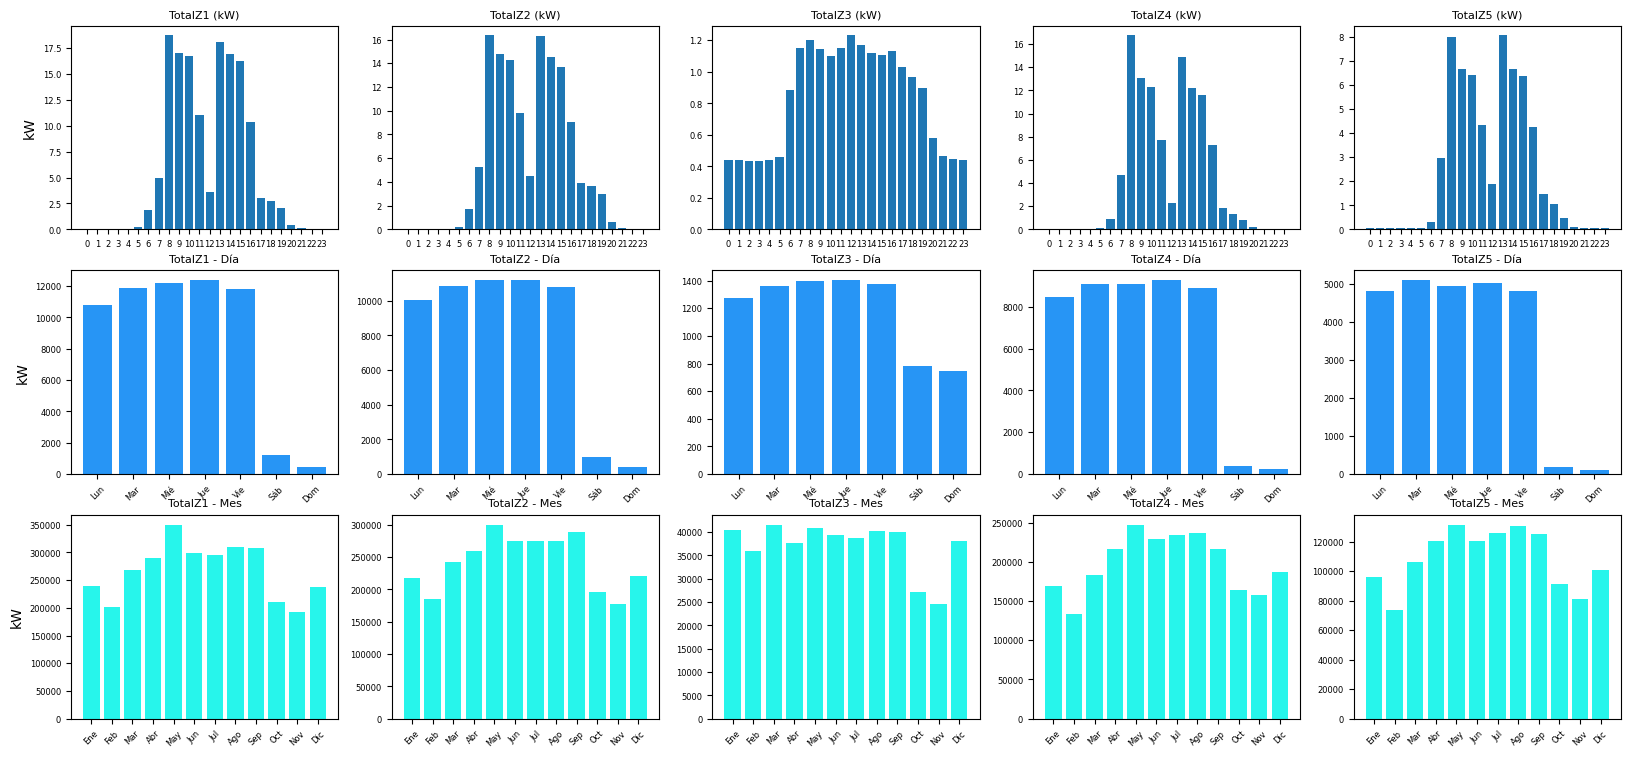

In [77]:
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"] # Para sustituirlo en el gráfico por el indice de los dias (0,1,2..)
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

# Para que salgan agrupadas las tablas 
n_cols = 5 
n_rows = 1 

total_rows = n_rows * 3 

fig, axes = plt.subplots(total_rows, n_cols, figsize=(20, 3 * total_rows))
axes = axes.reshape(total_rows, n_cols)

for i,col in enumerate(selected_cols): 

    row = i // n_cols
    col_pos = i % n_cols

    # Promedio por hora

    hourly_mean = df.groupby('Hour')[col].mean()

    axes[0, col_pos].bar(hourly_mean.index, hourly_mean.values)
    axes[0, col_pos].set_title(col + ' (kW)', fontsize=8)
    axes[0, col_pos].set_xticks(range(0, 24))
    axes[0, col_pos].tick_params(axis='both', labelsize=6)

    if(i == 0):
        axes[0, col_pos].set_ylabel('kW')    

    # Promedio por día de la semana 

    daily_sum = df.groupby('DateOnly')[col].sum() # Primero tenemos que agrupar por suma el dia completo (los datos vienen de hora en hora)
    daily_sum = daily_sum.to_frame()
    daily_sum['DayOfTheWeek'] = pd.to_datetime(daily_sum.index).dayofweek

    weekday_mean = daily_sum.groupby('DayOfTheWeek')[col].mean()

    axes[1, col_pos].bar(range(7), weekday_mean.values, color='#2795F5')
    axes[1, col_pos].set_title(f"{col} - Día", fontsize=8)
    axes[1, col_pos].set_xticks(range(7))
    axes[1, col_pos].set_xticklabels(dias, rotation=45)
    axes[1, col_pos].tick_params(axis='both', labelsize=6)
    if(i == 0):
        axes[1, col_pos].set_ylabel('kW')  

    # Promedio por mes 

    monthly_sum = df.groupby('YearMonth')[col].sum()

    monthly_mean = monthly_sum.groupby(monthly_sum.index.month).mean()

    axes[2, col_pos].bar(range(12), monthly_mean.values, color="#27F5EB")
    axes[2, col_pos].set_title(f"{col} - Mes", fontsize=8)
    axes[2, col_pos].set_xticks(range(12))
    axes[2, col_pos].set_xticklabels(meses, rotation=45)
    axes[2, col_pos].tick_params(axis='both', labelsize=6)
    if(i == 0):
        axes[2, col_pos].set_ylabel('kW')  

plt.show()